# NB-04B V4 — Screener S&P 500 

## Propósito


El objetivo no es optimizar todavía una cartera. El objetivo es comprobar si, al exigir que la nube visible actual esté en configuración alcista, mejora la calidad de las señales antes de pasar al backtest de cartera.

## Contrato de entrada V4

Una señal long válida debe cumplir simultáneamente:

1. Precio de cierre por encima del **Kumo actual**.
2. **Kumo actual alcista**: Senkou Span A actual > Senkou Span B actual.
3. **Kumo futuro alcista/favorable**: Senkou Span A futuro > Senkou Span B futuro.
4. Dos velas **Heiken Ashi alcistas** consecutivas.
5. La segunda vela Heiken Ashi —la señal actual— ocurre con precio por encima del Kumo.
6. Estocástico K cruza desde abajo hacia arriba a D.
7. Volumen relativo confirmado.
8. Liquidez suficiente.
9. Tenkan/Kijun se usa como **confirmación/ranking**, no como veto universal.

## Qué no hace este notebook

- No simula capital.
- No calcula rentabilidad de una cartera de 200.000 USD.
- No ejecuta reglas de salida Core50/Táctico50.
- No decide aún si el sistema es rentable como cartera.

Eso corresponde al 04C.

## Entregas

 tablas y gráficos agregados sobre todo el dataset procesado:

- señales por año;
- calidad forward a 5, 10, 20 y 40 días;
- comparación V3 vs V4;
- auditoría de condiciones obligatorias;
- diagnóstico Tenkan/Kijun;
- diagnóstico Chikou no vinculante;
- exportación limpia para el 04C si V4 queda aprobado.

In [1]:
# ============================================================
# 00 — IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 420)
pd.set_option("display.max_rows", 150)

# ------------------------------------------------------------
# Parámetros técnicos oficiales calibrados para el proyecto
# ------------------------------------------------------------
ICHIMOKU_TENKAN = 7
ICHIMOKU_KIJUN = 22
ICHIMOKU_SENKOU_B = 44
ICHIMOKU_SHIFT = 22

# ------------------------------------------------------------
# Contrato de entrada V4
# ------------------------------------------------------------
REQUIRE_PRICE_ABOVE_KUMO = True
REQUIRE_KUMO_ACTUAL_BULLISH = True       # NUEVO EN V4
REQUIRE_KUMO_FUTURE_BULLISH = True       # Se mantiene desde V3
REQUIRE_HA2_BULLISH = True
REQUIRE_STOCH_CROSS_UP = True
REQUIRE_VOLUME_CONFIRMATION = True
REQUIRE_LIQUIDITY = True

# Tenkan/Kijun: confirmación relevante, no veto universal.
TK_CROSS_RECENT_LOOKBACK = 5
TK_CONFIRMATION_WEIGHT = 2.0
TK_MATURITY_WEIGHT = 1.0

# Volumen/liquidez
MIN_VOLUME_REL_ENTRY = 1.00
MIN_DOLLAR_VOLUME = 10_000_000

# Evitar múltiples señales diarias repetidas mientras la condición permanece encendida.
GENERATE_ONLY_NEW_CONDITION_EVENTS = True
SIGNAL_COOLDOWN_DAYS = 5

# Métricas forward para auditar calidad de señal, no para seleccionar.
FORWARD_WINDOWS = [5, 10, 20, 40]

# Corte temporal oficial histórico. 2026 queda fuera.
ANALYSIS_START_DATE = pd.Timestamp("2018-01-01")
ANALYSIS_END_DATE = pd.Timestamp("2025-12-31")

# Rutas de entrada 04A
INPUT_DIR_CANDIDATES = [
    Path("outputs_nb04a_sp500_indicators"),
    Path("../outputs_nb04a_sp500_indicators"),
    Path("/Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators"),
]

# Rutas de salida V4
OUTPUT_DIR = Path("outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DAILY_AUDIT_CSV = OUTPUT_DIR / "df_nb04b_v4_daily_audit.csv"
DAILY_AUDIT_PARQUET = OUTPUT_DIR / "df_nb04b_v4_daily_audit.parquet"
CANDIDATES_CSV = OUTPUT_DIR / "df_nb04b_v4_entry_candidates.csv"
CANDIDATES_PARQUET = OUTPUT_DIR / "df_nb04b_v4_entry_candidates.parquet"
SUMMARY_GLOBAL_CSV = OUTPUT_DIR / "summary_nb04b_v4_global.csv"
SUMMARY_BY_YEAR_CSV = OUTPUT_DIR / "summary_nb04b_v4_by_year.csv"
SUMMARY_BY_FAMILY_CSV = OUTPUT_DIR / "summary_nb04b_v4_by_family.csv"
SUMMARY_BY_TK_CSV = OUTPUT_DIR / "summary_nb04b_v4_by_tk_confirmation.csv"
SUMMARY_BY_CHIKOU_CSV = OUTPUT_DIR / "summary_nb04b_v4_by_chikou_diagnostic.csv"
SUMMARY_HORIZON_CSV = OUTPUT_DIR / "summary_nb04b_v4_forward_horizon_completeness.csv"
SUMMARY_V3_V4_COMPARISON_CSV = OUTPUT_DIR / "summary_nb04b_v3_vs_v4_comparison.csv"
SUMMARY_JSON = OUTPUT_DIR / "summary_nb04b_v4.json"

# Rutas opcionales para comparación contra V3
V3_CANDIDATE_PATHS = [
    Path("outputs_nb04b_screener_ha2_stoch_kumo_contract/df_nb04b_v3_entry_candidates.csv"),
    Path("../outputs_nb04b_screener_ha2_stoch_kumo_contract/df_nb04b_v3_entry_candidates.csv"),
    Path("/Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_contract/df_nb04b_v3_entry_candidates.csv"),
]

run_timestamp = datetime.now().isoformat(timespec="seconds")
print("Run timestamp:", run_timestamp)
print("Output dir:", OUTPUT_DIR.resolve())

Run timestamp: 2026-05-20T10:27:56
Output dir: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4


## 1. Carga del dataset generado por NB-04A

El 04B no descarga precios. Consume el dataset técnico validado antes. 

También aplica el corte histórico oficial 2018-2025 antes de calcular señales y forward returns, para que 2026 no contamine los resultados.

In [2]:
# ============================================================
# 01 — CARGA DEL DATASET NB-04A
# ============================================================

def find_input_file():
    for d in INPUT_DIR_CANDIDATES:
        parquet_path = d / "sp500_indicators_ichimoku_7_22_44.parquet"
        csv_path = d / "sp500_indicators_ichimoku_7_22_44.csv"
        if parquet_path.exists():
            return parquet_path
        if csv_path.exists():
            return csv_path
    raise FileNotFoundError(
        "No encontré el dataset de NB-04A. Busqué en:\n" +
        "\n".join(str(p.resolve()) for p in INPUT_DIR_CANDIDATES)
    )

input_path = find_input_file()
print("Archivo NB-04A encontrado:", input_path.resolve())

if input_path.suffix.lower() == ".parquet":
    df_raw = pd.read_parquet(input_path)
else:
    df_raw = pd.read_csv(input_path)

df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values(["Ticker", "Date"]).reset_index(drop=True)

full_min = df_raw["Date"].min()
full_max = df_raw["Date"].max()
full_rows = len(df_raw)
full_tickers = df_raw["Ticker"].nunique()

mask_period = (df_raw["Date"] >= ANALYSIS_START_DATE) & (df_raw["Date"] <= ANALYSIS_END_DATE)
df = df_raw.loc[mask_period].copy().reset_index(drop=True)

print("Dataset completo:", df_raw.shape, "| Tickers:", full_tickers, "| Fechas:", full_min.date(), "→", full_max.date())
print("Dataset usado 04B V4:", df.shape, "| Tickers:", df["Ticker"].nunique(), "| Fechas:", df["Date"].min().date(), "→", df["Date"].max().date())

if df["Date"].max() > ANALYSIS_END_DATE:
    raise AssertionError("El dataset usado contiene fechas posteriores al corte 2025-12-31.")

Archivo NB-04A encontrado: /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.parquet
Dataset completo: (1037988, 72) | Tickers: 503 | Fechas: 2018-01-02 → 2026-05-19
Dataset usado 04B V4: (990203, 72) | Tickers: 503 | Fechas: 2018-01-02 → 2025-12-31


## 2. Validación de columnas mínimas

Se exige la presencia de todas las columnas necesarias para reconstruir el contrato de entrada. Si falta alguna, el notebook se detiene.

In [3]:
# ============================================================
# 02 — VALIDACIÓN DE COLUMNAS
# ============================================================

required_cols = [
    "Ticker", "Date",
    "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume",
    "Ichimoku_Tenkan", "Ichimoku_Kijun",
    "Ichimoku_Senkou_A", "Ichimoku_Senkou_B",
    "HA_Open", "HA_Close", "HA_Bullish", "HA_Bearish",
    "SMA5", "Stoch_K", "Stoch_D",
    "Volume_Rel", "Dollar_Volume_MA20",
    "row_operational_ok"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    print("Columnas disponibles:")
    print(list(df.columns))
    raise ValueError(f"Faltan columnas necesarias para NB-04B V4: {missing}")

print("Validación de columnas OK.")

Validación de columnas OK.


## 3. Reconstrucción diaria de condiciones técnicas

Esta sección calcula todas las condiciones necesarias para el contrato V4:

- Kumo actual visible en la fecha operativa.
- Kumo futuro proyectado.
- Precio por encima del Kumo actual.
- Kumo actual alcista.
- Kumo futuro alcista.
- Dos velas Heiken Ashi alcistas.
- Estocástico cruzando al alza.
- Volumen y liquidez.
- Tenkan/Kijun como confirmación/ranking.
- Chikou como diagnóstico no vinculante.

La condición **V4** se diferencia de V3 porque exige:

```python
kumo_actual_alcista == True
```

además del Kumo futuro alcista.

In [4]:
# ============================================================
# 03 — CONDICIONES TÉCNICAS DIARIAS
# ============================================================

def as_bool(s):
    return s.fillna(False).astype(bool)


def build_daily_conditions(df):
    df = df.copy().sort_values(["Ticker", "Date"]).reset_index(drop=True)
    g = df.groupby("Ticker", group_keys=False)

    # Kumo actual: las líneas Senkou están calculadas/proyectadas con shift.
    # Para evaluar el Kumo visible en la fecha t, se traen 22 sesiones hacia atrás.
    df["Senkou_A_actual"] = g["Ichimoku_Senkou_A"].shift(ICHIMOKU_SHIFT)
    df["Senkou_B_actual"] = g["Ichimoku_Senkou_B"].shift(ICHIMOKU_SHIFT)
    df["Senkou_A_futuro"] = df["Ichimoku_Senkou_A"]
    df["Senkou_B_futuro"] = df["Ichimoku_Senkou_B"]

    df["Kumo_Actual_Top"] = df[["Senkou_A_actual", "Senkou_B_actual"]].max(axis=1)
    df["Kumo_Actual_Bottom"] = df[["Senkou_A_actual", "Senkou_B_actual"]].min(axis=1)
    df["Kumo_Futuro_Top"] = df[["Senkou_A_futuro", "Senkou_B_futuro"]].max(axis=1)
    df["Kumo_Futuro_Bottom"] = df[["Senkou_A_futuro", "Senkou_B_futuro"]].min(axis=1)

    close = df["Close_Adj"]

    # Condición básica Ichimoku long: precio fuera y arriba de la nube.
    df["precio_sobre_kumo_actual"] = close > df["Kumo_Actual_Top"]
    df["precio_dentro_kumo_actual"] = (close <= df["Kumo_Actual_Top"]) & (close >= df["Kumo_Actual_Bottom"])
    df["precio_bajo_kumo_actual"] = close < df["Kumo_Actual_Bottom"]

    # Sentimiento del Kumo.
    df["kumo_actual_alcista"] = df["Senkou_A_actual"] > df["Senkou_B_actual"]
    df["kumo_futuro_alcista"] = df["Senkou_A_futuro"] > df["Senkou_B_futuro"]

    # V4 exige ambas: nube actual verde y nube futura favorable.
    df["kumo_alcista_requerido"] = df["kumo_actual_alcista"] & df["kumo_futuro_alcista"]

    # Grosor de Kumo como diagnóstico, no filtro duro.
    df["kumo_actual_thickness_abs"] = (df["Kumo_Actual_Top"] - df["Kumo_Actual_Bottom"]).abs()
    df["kumo_actual_thickness_pct"] = df["kumo_actual_thickness_abs"] / df["Close_Adj"]

    # Heiken Ashi: dos velas alcistas consecutivas. La segunda es la actual.
    df["HA_Bullish"] = as_bool(df["HA_Bullish"])
    df["HA_Bullish_prev1"] = g["HA_Bullish"].shift(1).fillna(False).astype(bool)
    df["HA2_Bullish"] = df["HA_Bullish"] & df["HA_Bullish_prev1"]
    df["HA2_Bullish_sobre_kumo"] = df["HA2_Bullish"] & df["precio_sobre_kumo_actual"]

    # Estocástico: cruce de K sobre D desde abajo hacia arriba.
    df["Stoch_K_prev1"] = g["Stoch_K"].shift(1)
    df["Stoch_D_prev1"] = g["Stoch_D"].shift(1)
    df["stoch_cross_up"] = (
        (df["Stoch_K_prev1"] <= df["Stoch_D_prev1"]) &
        (df["Stoch_K"] > df["Stoch_D"])
    )
    df["stoch_cross_up_from_below"] = df["stoch_cross_up"]
    df["stoch_not_extreme_overbought"] = df["Stoch_K"] < 80

    # Tenkan/Kijun: confirmación/madurez, no veto universal.
    df["Tenkan_prev1"] = g["Ichimoku_Tenkan"].shift(1)
    df["Kijun_prev1"] = g["Ichimoku_Kijun"].shift(1)
    df["tenkan_sobre_kijun"] = df["Ichimoku_Tenkan"] > df["Ichimoku_Kijun"]
    df["tk_cross_up_today"] = (
        (df["Tenkan_prev1"] <= df["Kijun_prev1"]) &
        (df["Ichimoku_Tenkan"] > df["Ichimoku_Kijun"])
    )
    df["tk_cross_up_recent"] = (
        df.groupby("Ticker")["tk_cross_up_today"]
        .rolling(TK_CROSS_RECENT_LOOKBACK, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
        .fillna(False)
        .astype(bool)
    )

    df["precio_sobre_tenkan"] = close > df["Ichimoku_Tenkan"]
    df["precio_sobre_kijun"] = close > df["Ichimoku_Kijun"]
    df["precio_sobre_tenkan_y_kijun"] = df["precio_sobre_tenkan"] & df["precio_sobre_kijun"]

    # Chikou: diagnóstico no vinculante para no mezclar cambios de contrato.
    # Se aproxima comparando el cierre actual con el cierre y Kumo visible de hace 22 sesiones.
    df["Close_22ago"] = g["Close_Adj"].shift(ICHIMOKU_SHIFT)
    df["High_22ago"] = g["High_Adj"].shift(ICHIMOKU_SHIFT)
    df["Kumo_Actual_Top_22ago"] = g["Kumo_Actual_Top"].shift(ICHIMOKU_SHIFT)
    df["Kumo_Actual_Bottom_22ago"] = g["Kumo_Actual_Bottom"].shift(ICHIMOKU_SHIFT)
    df["chikou_above_close_22ago"] = df["Close_Adj"] > df["Close_22ago"]
    df["chikou_above_high_22ago"] = df["Close_Adj"] > df["High_22ago"]
    df["chikou_above_kumo_22ago"] = df["Close_Adj"] > df["Kumo_Actual_Top_22ago"]
    df["chikou_diagnostic_status"] = np.select(
        [
            df["chikou_above_high_22ago"].fillna(False) & df["chikou_above_kumo_22ago"].fillna(False),
            df["chikou_above_close_22ago"].fillna(False),
        ],
        [
            "chikou_libre_sobre_precio_y_kumo_22ago",
            "chikou_parcial_sobre_close_22ago",
        ],
        default="chikou_no_confirmado_o_sin_historia"
    )

    # Volumen y liquidez.
    df["volume_confirmed"] = df["Volume_Rel"] >= MIN_VOLUME_REL_ENTRY
    df["liquidity_ok"] = df["Dollar_Volume_MA20"] >= MIN_DOLLAR_VOLUME

    # Condición base de entrada V4.
    df["entry_condition_base"] = (
        as_bool(df["row_operational_ok"]) &
        df["precio_sobre_kumo_actual"].fillna(False) &
        df["kumo_actual_alcista"].fillna(False) &
        df["kumo_futuro_alcista"].fillna(False) &
        df["HA2_Bullish_sobre_kumo"].fillna(False) &
        df["stoch_cross_up_from_below"].fillna(False) &
        df["volume_confirmed"].fillna(False) &
        df["liquidity_ok"].fillna(False)
    )

    # Evento nuevo: primera fecha en la que se enciende la condición tras venir apagada.
    df["entry_condition_base_prev1"] = g["entry_condition_base"].shift(1).fillna(False).astype(bool)
    df["entry_event_new_condition"] = df["entry_condition_base"] & (~df["entry_condition_base_prev1"])

    # Cooldown por ticker.
    tmp = df[["Ticker", "Date", "entry_event_new_condition"]].copy()
    cooldown_ok = []
    for ticker, part in tmp.groupby("Ticker", sort=False):
        last_date = None
        for _, row in part.iterrows():
            if bool(row["entry_event_new_condition"]):
                if last_date is None or (row["Date"] - last_date).days >= SIGNAL_COOLDOWN_DAYS:
                    cooldown_ok.append(True)
                    last_date = row["Date"]
                else:
                    cooldown_ok.append(False)
            else:
                cooldown_ok.append(False)
    df["entry_event_after_cooldown"] = cooldown_ok

    # Clasificación Tenkan/Kijun.
    df["tk_confirmation_status"] = np.select(
        [
            df["tk_cross_up_recent"].fillna(False),
            df["tenkan_sobre_kijun"].fillna(False),
        ],
        [
            "tk_cross_up_recent",
            "tk_mature_above_kijun_no_recent_cross",
        ],
        default="no_tk_confirmation_yet"
    )

    df["entry_family"] = np.select(
        [
            df["entry_condition_base"] & df["tk_cross_up_recent"],
            df["entry_condition_base"] & (~df["tk_cross_up_recent"]) & df["tenkan_sobre_kijun"],
            df["entry_condition_base"] & (~df["tenkan_sobre_kijun"]),
        ],
        [
            "v4_kumo_actual_y_futuro_alcista_con_tk_cross",
            "v4_kumo_actual_y_futuro_alcista_tk_maduro",
            "v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado",
        ],
        default="no_entry"
    )

    # Score solo ordena candidatos ya válidos.
    df["technical_priority_score"] = 0.0
    df.loc[df["precio_sobre_kumo_actual"], "technical_priority_score"] += 2.0
    df.loc[df["kumo_actual_alcista"], "technical_priority_score"] += 1.0
    df.loc[df["kumo_futuro_alcista"], "technical_priority_score"] += 1.0
    df.loc[df["HA2_Bullish_sobre_kumo"], "technical_priority_score"] += 1.5
    df.loc[df["stoch_cross_up_from_below"], "technical_priority_score"] += 1.5
    df.loc[df["volume_confirmed"], "technical_priority_score"] += 1.0
    df.loc[df["liquidity_ok"], "technical_priority_score"] += 0.5
    df.loc[df["tk_cross_up_recent"], "technical_priority_score"] += TK_CONFIRMATION_WEIGHT
    df.loc[(~df["tk_cross_up_recent"]) & df["tenkan_sobre_kijun"], "technical_priority_score"] += TK_MATURITY_WEIGHT
    df.loc[df["precio_sobre_tenkan_y_kijun"], "technical_priority_score"] += 0.5
    df.loc[df["stoch_not_extreme_overbought"], "technical_priority_score"] += 0.25
    df.loc[df["chikou_above_high_22ago"] & df["chikou_above_kumo_22ago"], "technical_priority_score"] += 0.5

    return df


df_audit = build_daily_conditions(df)

print("Daily audit construido:", df_audit.shape)
print("Fechas:", df_audit["Date"].min().date(), "→", df_audit["Date"].max().date())
print("Tickers:", df_audit["Ticker"].nunique())
print("Filas con condición base V4:", int(df_audit["entry_condition_base"].sum()))
print("Eventos nuevos de entrada V4:", int(df_audit["entry_event_new_condition"].sum()))
print("Eventos tras cooldown V4:", int(df_audit["entry_event_after_cooldown"].sum()))

Daily audit construido: (990203, 118)
Fechas: 2018-01-02 → 2025-12-31
Tickers: 503
Filas con condición base V4: 8746
Eventos nuevos de entrada V4: 8746
Eventos tras cooldown V4: 8155


## 4. Construcción de candidatos operativos

Se generan candidatos solo cuando se activa un evento nuevo de entrada V4. Tenkan/Kijun clasifica prioridad, pero no habilita ni bloquea la entrada.

In [5]:
# ============================================================
# 04 — CANDIDATOS OPERATIVOS V4
# ============================================================

candidate_mask = df_audit["entry_event_after_cooldown"] if GENERATE_ONLY_NEW_CONDITION_EVENTS else df_audit["entry_condition_base"]
df_candidates = df_audit.loc[candidate_mask].copy().reset_index(drop=True)

if len(df_candidates) == 0:
    raise RuntimeError("No se generaron candidatos V4. Revisar si la condición de Kumo actual alcista quedó demasiado restrictiva.")

df_candidates["signal_date"] = df_candidates["Date"]
df_candidates["candidate_entry_date"] = df_candidates["Date"]
df_candidates["entry_timing"] = "T0"
df_candidates["delay_days"] = 0
df_candidates["source_signal_block"] = "T0_HA2_STOCH_KUMO_ACTUAL_Y_FUTURO_ALCISTA_VOLUME"
df_candidates["accepted_signal"] = True
df_candidates["Year"] = df_candidates["Date"].dt.year

# Validaciones duras del contrato V4.
checks = {
    "precio_sobre_kumo_actual": df_candidates["precio_sobre_kumo_actual"].fillna(False).all(),
    "kumo_actual_alcista": df_candidates["kumo_actual_alcista"].fillna(False).all(),
    "kumo_futuro_alcista": df_candidates["kumo_futuro_alcista"].fillna(False).all(),
    "HA2_Bullish_sobre_kumo": df_candidates["HA2_Bullish_sobre_kumo"].fillna(False).all(),
    "stoch_cross_up_from_below": df_candidates["stoch_cross_up_from_below"].fillna(False).all(),
    "volume_confirmed": df_candidates["volume_confirmed"].fillna(False).all(),
    "liquidity_ok": df_candidates["liquidity_ok"].fillna(False).all(),
    "no_2026_candidates": (df_candidates["Date"] <= ANALYSIS_END_DATE).all(),
}

failed = [k for k, ok in checks.items() if not bool(ok)]
if failed:
    raise AssertionError("Fallan condiciones obligatorias V4: " + ", ".join(failed))

print("Candidatos V4 generados:", len(df_candidates))
print("Tickers con candidatos V4:", df_candidates["Ticker"].nunique())
print("Fechas V4:", df_candidates["Date"].min().date(), "→", df_candidates["Date"].max().date())
print("Todas las condiciones obligatorias V4 están OK.")

Candidatos V4 generados: 8155
Tickers con candidatos V4: 502
Fechas V4: 2018-04-16 → 2025-12-22
Todas las condiciones obligatorias V4 están OK.


## 5. Métricas forward para auditar calidad de señal

Estas métricas **no crean señales** y no representan una cartera. Solo evalúan qué ocurrió después de cada señal válida V4 a horizontes fijos.

Importante: como el dataset usado está cortado al 31/12/2025, las señales de final de 2025 pueden no tener horizonte completo a 20 o 40 días. Por eso se agrega una tabla de completitud de horizonte.

In [6]:
# ============================================================
# 05 — MÉTRICAS FORWARD
# ============================================================

def add_forward_metrics(df, windows):
    df = df.copy().sort_values(["Ticker", "Date"]).reset_index(drop=True)
    g = df.groupby("Ticker", group_keys=False)
    for w in windows:
        df[f"ret_fwd_{w}d"] = g["Close_Adj"].shift(-w) / df["Close_Adj"] - 1
        df[f"future_high_{w}d"] = g["High_Adj"].transform(
            lambda s: s.shift(-1).rolling(window=w, min_periods=1).max().shift(-(w-1))
        )
        df[f"future_low_{w}d"] = g["Low_Adj"].transform(
            lambda s: s.shift(-1).rolling(window=w, min_periods=1).min().shift(-(w-1))
        )
        df[f"mfe_fwd_{w}d"] = df[f"future_high_{w}d"] / df["Close_Adj"] - 1
        df[f"mae_fwd_{w}d"] = df[f"future_low_{w}d"] / df["Close_Adj"] - 1
    return df


df_audit = add_forward_metrics(df_audit, FORWARD_WINDOWS)

forward_cols = []
for w in FORWARD_WINDOWS:
    forward_cols += [f"ret_fwd_{w}d", f"mfe_fwd_{w}d", f"mae_fwd_{w}d"]

df_candidates = df_candidates.drop(columns=[c for c in forward_cols if c in df_candidates.columns], errors="ignore")
df_candidates = df_candidates.merge(
    df_audit[["Ticker", "Date"] + forward_cols],
    on=["Ticker", "Date"],
    how="left"
)

# Completitud de horizontes por año.
horizon_rows = []
for year, part in df_candidates.groupby("Year"):
    row = {"Year": int(year), "n_candidates": len(part)}
    for w in FORWARD_WINDOWS:
        row[f"valid_ret_{w}d"] = int(part[f"ret_fwd_{w}d"].notna().sum())
        row[f"pct_valid_ret_{w}d"] = float(part[f"ret_fwd_{w}d"].notna().mean())
    horizon_rows.append(row)
summary_horizon = pd.DataFrame(horizon_rows).sort_values("Year")

print("Métricas forward agregadas.")
display(summary_horizon.style.format({c: "{:.2%}" for c in summary_horizon.columns if c.startswith("pct_")}))

Métricas forward agregadas.


,Year,n_candidates,valid_ret_5d,pct_valid_ret_5d,valid_ret_10d,pct_valid_ret_10d,valid_ret_20d,pct_valid_ret_20d,valid_ret_40d,pct_valid_ret_40d
0,2018,741,741,100.00%,741,100.00%,741,100.00%,741,100.00%
1,2019,1158,1158,100.00%,1158,100.00%,1158,100.00%,1158,100.00%
2,2020,1189,1189,100.00%,1189,100.00%,1189,100.00%,1189,100.00%
3,2021,1335,1335,100.00%,1335,100.00%,1335,100.00%,1335,100.00%
4,2022,472,472,100.00%,472,100.00%,472,100.00%,472,100.00%
5,2023,907,907,100.00%,907,100.00%,907,100.00%,907,100.00%
6,2024,1429,1429,100.00%,1429,100.00%,1429,100.00%,1429,100.00%
7,2025,924,924,100.00%,908,98.27%,865,93.61%,785,84.96%


## 6. Resúmenes agregados V4

Todas las conclusiones deben salir de estas tablas agregadas, calculadas sobre el conjunto completo de candidatos V4.

In [7]:
# ============================================================
# 06 — RESÚMENES AGREGADOS V4
# ============================================================

def pct_pos(x):
    x = pd.Series(x).dropna()
    return np.nan if len(x) == 0 else (x > 0).mean()

def pct_neg(x):
    x = pd.Series(x).dropna()
    return np.nan if len(x) == 0 else (x < 0).mean()

summary_global = pd.DataFrame([{
    "run_timestamp": run_timestamp,
    "analysis_start_date": str(ANALYSIS_START_DATE.date()),
    "analysis_end_date": str(ANALYSIS_END_DATE.date()),
    "input_rows_full": int(full_rows),
    "input_tickers_full": int(full_tickers),
    "input_full_min_date": str(full_min.date()),
    "input_full_max_date": str(full_max.date()),
    "rows_used": int(len(df_audit)),
    "tickers_used": int(df_audit["Ticker"].nunique()),
    "n_candidates": int(len(df_candidates)),
    "n_candidate_tickers": int(df_candidates["Ticker"].nunique()),
    "n_candidates_price_above_kumo": int(df_candidates["precio_sobre_kumo_actual"].sum()),
    "n_candidates_kumo_actual_bullish": int(df_candidates["kumo_actual_alcista"].sum()),
    "n_candidates_kumo_future_bullish": int(df_candidates["kumo_futuro_alcista"].sum()),
    "n_candidates_ha2_bullish": int(df_candidates["HA2_Bullish_sobre_kumo"].sum()),
    "n_candidates_stoch_cross_up": int(df_candidates["stoch_cross_up_from_below"].sum()),
    "n_candidates_volume_confirmed": int(df_candidates["volume_confirmed"].sum()),
    "n_candidates_tk_cross_recent": int(df_candidates["tk_cross_up_recent"].sum()),
    "pct_tk_cross_recent": float(df_candidates["tk_cross_up_recent"].mean()),
    "pct_tk_mature": float(df_candidates["tenkan_sobre_kijun"].mean()),
    "pct_chikou_free": float((df_candidates["chikou_diagnostic_status"] == "chikou_libre_sobre_precio_y_kumo_22ago").mean()),
    "ret20_mean": float(df_candidates["ret_fwd_20d"].mean()),
    "ret20_median": float(df_candidates["ret_fwd_20d"].median()),
    "pct_pos_20d": float(pct_pos(df_candidates["ret_fwd_20d"])),
    "pct_neg_20d": float(pct_neg(df_candidates["ret_fwd_20d"])),
    "mfe20_mean": float(df_candidates["mfe_fwd_20d"].mean()),
    "mae20_mean": float(df_candidates["mae_fwd_20d"].mean()),
}])

summary_by_year = (
    df_candidates
    .groupby("Year")
    .agg(
        n_candidates=("Ticker", "count"),
        n_tickers=("Ticker", "nunique"),
        pct_tk_cross_recent=("tk_cross_up_recent", "mean"),
        pct_tk_mature=("tenkan_sobre_kijun", "mean"),
        pct_chikou_free=("chikou_diagnostic_status", lambda x: (x == "chikou_libre_sobre_precio_y_kumo_22ago").mean()),
        avg_score=("technical_priority_score", "mean"),
        ret5_mean=("ret_fwd_5d", "mean"),
        ret10_mean=("ret_fwd_10d", "mean"),
        ret20_mean=("ret_fwd_20d", "mean"),
        ret20_median=("ret_fwd_20d", "median"),
        pct_pos_20d=("ret_fwd_20d", pct_pos),
        pct_neg_20d=("ret_fwd_20d", pct_neg),
        mfe20_mean=("mfe_fwd_20d", "mean"),
        mae20_mean=("mae_fwd_20d", "mean"),
    )
    .reset_index()
)

summary_by_family = (
    df_candidates
    .groupby("entry_family")
    .agg(
        n_candidates=("Ticker", "count"),
        n_tickers=("Ticker", "nunique"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        pct_tk_cross_recent=("tk_cross_up_recent", "mean"),
        pct_tk_mature=("tenkan_sobre_kijun", "mean"),
        pct_chikou_free=("chikou_diagnostic_status", lambda x: (x == "chikou_libre_sobre_precio_y_kumo_22ago").mean()),
        avg_score=("technical_priority_score", "mean"),
        ret5_mean=("ret_fwd_5d", "mean"),
        ret10_mean=("ret_fwd_10d", "mean"),
        ret20_mean=("ret_fwd_20d", "mean"),
        ret20_median=("ret_fwd_20d", "median"),
        pct_pos_20d=("ret_fwd_20d", pct_pos),
        pct_neg_20d=("ret_fwd_20d", pct_neg),
        mfe20_mean=("mfe_fwd_20d", "mean"),
        mae20_mean=("mae_fwd_20d", "mean"),
    )
    .reset_index()
    .sort_values("n_candidates", ascending=False)
)

summary_by_tk = (
    df_candidates
    .groupby("tk_confirmation_status")
    .agg(
        n_candidates=("Ticker", "count"),
        n_tickers=("Ticker", "nunique"),
        pct_chikou_free=("chikou_diagnostic_status", lambda x: (x == "chikou_libre_sobre_precio_y_kumo_22ago").mean()),
        avg_score=("technical_priority_score", "mean"),
        ret5_mean=("ret_fwd_5d", "mean"),
        ret10_mean=("ret_fwd_10d", "mean"),
        ret20_mean=("ret_fwd_20d", "mean"),
        ret20_median=("ret_fwd_20d", "median"),
        pct_pos_20d=("ret_fwd_20d", pct_pos),
        pct_neg_20d=("ret_fwd_20d", pct_neg),
        mfe20_mean=("mfe_fwd_20d", "mean"),
        mae20_mean=("mae_fwd_20d", "mean"),
    )
    .reset_index()
    .sort_values("n_candidates", ascending=False)
)

summary_by_chikou = (
    df_candidates
    .groupby("chikou_diagnostic_status")
    .agg(
        n_candidates=("Ticker", "count"),
        n_tickers=("Ticker", "nunique"),
        pct_tk_cross_recent=("tk_cross_up_recent", "mean"),
        avg_score=("technical_priority_score", "mean"),
        ret5_mean=("ret_fwd_5d", "mean"),
        ret10_mean=("ret_fwd_10d", "mean"),
        ret20_mean=("ret_fwd_20d", "mean"),
        ret20_median=("ret_fwd_20d", "median"),
        pct_pos_20d=("ret_fwd_20d", pct_pos),
        pct_neg_20d=("ret_fwd_20d", pct_neg),
        mfe20_mean=("mfe_fwd_20d", "mean"),
        mae20_mean=("mae_fwd_20d", "mean"),
    )
    .reset_index()
    .sort_values("n_candidates", ascending=False)
)

fmt = {
    "pct_tk_cross_recent": "{:.2%}", "pct_tk_mature": "{:.2%}", "pct_chikou_free": "{:.2%}",
    "avg_score": "{:.2f}",
    "ret5_mean": "{:.2%}", "ret10_mean": "{:.2%}", "ret20_mean": "{:.2%}", "ret20_median": "{:.2%}",
    "pct_pos_20d": "{:.2%}", "pct_neg_20d": "{:.2%}", "mfe20_mean": "{:.2%}", "mae20_mean": "{:.2%}",
}

print("Resumen global V4")
display(summary_global.T)

print("Resumen por año V4")
display(summary_by_year.style.format(fmt))

print("Resumen por familia V4")
display(summary_by_family.style.format(fmt))

print("Resumen por confirmación Tenkan/Kijun V4")
display(summary_by_tk.style.format(fmt))

print("Resumen por diagnóstico Chikou V4 — diagnóstico, no filtro")
display(summary_by_chikou.style.format(fmt))

Resumen global V4


,0
run_timestamp,2026-05-20T10:27:56
analysis_start_date,2018-01-01
analysis_end_date,2025-12-31
input_rows_full,1037988
input_tickers_full,503
input_full_min_date,2018-01-02
input_full_max_date,2026-05-19
rows_used,990203
tickers_used,503
n_candidates,8155


Resumen por año V4


,Year,n_candidates,n_tickers,pct_tk_cross_recent,pct_tk_mature,pct_chikou_free,avg_score,ret5_mean,ret10_mean,ret20_mean,ret20_median,pct_pos_20d,pct_neg_20d,mfe20_mean,mae20_mean
0,2018,741,322,16.46%,91.77%,95.01%,10.59,-0.51%,-0.41%,-0.76%,-0.42%,47.91%,52.09%,4.37%,-5.92%
1,2019,1158,417,19.86%,89.90%,93.70%,10.60,0.06%,0.47%,0.91%,1.34%,60.88%,38.86%,4.75%,-4.30%
2,2020,1189,422,18.50%,90.92%,93.52%,10.59,-0.22%,-0.12%,-0.43%,0.52%,52.65%,47.35%,7.18%,-7.97%
3,2021,1335,442,20.75%,92.21%,94.38%,10.63,0.54%,0.59%,1.07%,1.11%,56.33%,43.67%,6.68%,-5.79%
4,2022,472,238,19.92%,86.44%,91.10%,10.55,-0.62%,-1.33%,-1.05%,-1.18%,44.07%,55.93%,5.83%,-7.86%
5,2023,907,382,21.17%,90.85%,93.50%,10.61,0.25%,0.32%,0.25%,0.01%,50.17%,49.72%,5.83%,-5.47%
6,2024,1429,449,20.92%,90.55%,94.33%,10.61,0.35%,0.99%,2.52%,1.81%,61.44%,38.56%,7.09%,-4.65%
7,2025,924,382,23.59%,89.94%,94.16%,10.63,0.25%,0.93%,1.68%,0.99%,55.61%,44.39%,7.54%,-6.10%


Resumen por familia V4


,entry_family,n_candidates,n_tickers,first_date,last_date,pct_tk_cross_recent,pct_tk_mature,pct_chikou_free,avg_score,ret5_mean,ret10_mean,ret20_mean,ret20_median,pct_pos_20d,pct_neg_20d,mfe20_mean,mae20_mean
2,v4_kumo_actual_y_futuro_alcista_tk_maduro,5763,501,2018-04-16 00:00:00,2025-12-19 00:00:00,0.00%,100.00%,98.79%,10.52,0.07%,0.33%,0.64%,0.69%,54.29%,45.66%,6.14%,-5.83%
0,v4_kumo_actual_y_futuro_alcista_con_tk_cross,1652,480,2018-04-16 00:00:00,2025-12-22 00:00:00,100.00%,98.49%,88.92%,11.47,0.06%,0.30%,0.98%,1.19%,57.12%,42.82%,6.54%,-5.87%
1,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,740,384,2018-04-16 00:00:00,2025-12-19 00:00:00,0.00%,0.00%,66.89%,9.38,0.46%,0.53%,1.29%,1.42%,56.83%,43.17%,6.84%,-5.72%


Resumen por confirmación Tenkan/Kijun V4


,tk_confirmation_status,n_candidates,n_tickers,pct_chikou_free,avg_score,ret5_mean,ret10_mean,ret20_mean,ret20_median,pct_pos_20d,pct_neg_20d,mfe20_mean,mae20_mean
2,tk_mature_above_kijun_no_recent_cross,5763,501,98.79%,10.52,0.07%,0.33%,0.64%,0.69%,54.29%,45.66%,6.14%,-5.83%
1,tk_cross_up_recent,1652,480,88.92%,11.47,0.06%,0.30%,0.98%,1.19%,57.12%,42.82%,6.54%,-5.87%
0,no_tk_confirmation_yet,740,384,66.89%,9.38,0.46%,0.53%,1.29%,1.42%,56.83%,43.17%,6.84%,-5.72%


Resumen por diagnóstico Chikou V4 — diagnóstico, no filtro


,chikou_diagnostic_status,n_candidates,n_tickers,pct_tk_cross_recent,avg_score,ret5_mean,ret10_mean,ret20_mean,ret20_median,pct_pos_20d,pct_neg_20d,mfe20_mean,mae20_mean
0,chikou_libre_sobre_precio_y_kumo_22ago,7657,502,19.19%,10.65,0.11%,0.37%,0.79%,0.88%,55.33%,44.63%,6.29%,-5.78%
1,chikou_no_confirmado_o_sin_historia,280,211,26.43%,9.59,0.20%,-0.05%,0.20%,-0.01%,50.00%,50.00%,6.33%,-6.59%
2,chikou_parcial_sobre_close_22ago,218,178,50.00%,10.29,-0.28%,0.00%,0.58%,0.47%,53.24%,46.30%,6.23%,-6.36%


Candidatos V3 encontrados: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_contract/df_nb04b_v3_entry_candidates.csv
Resumen retención V3 → V4


,n_v3_unique_signals,n_v4_unique_signals,n_v3_retained_by_v4,n_v3_removed_by_v4,pct_v3_retained,pct_v3_removed
0,12369,8155,8113,4256,65.59%,34.41%


Comparación global V3 vs V4


,version,n_candidates,n_tickers,first_date,last_date,ret5_mean,ret10_mean,ret20_mean,ret20_median,pct_pos_20d,mfe20_mean,mae20_mean
0,V3,12369,502,2018-04-13 00:00:00,2025-12-22 00:00:00,0.15%,0.40%,0.78%,0.89%,55.37%,6.39%,-5.82%
1,V4,8155,502,2018-04-16 00:00:00,2025-12-22 00:00:00,0.10%,0.34%,0.77%,0.84%,55.09%,6.29%,-5.83%


Comparación por año V3 vs V4


,Year,n_candidates,ret20_mean,ret20_median,pct_pos_20d,version
0,2018,1071,-1.20%,-0.61%,46.31%,V3
8,2018,741,-0.76%,-0.42%,47.91%,V4
1,2019,1768,1.25%,1.67%,63.01%,V3
9,2019,1158,0.91%,1.34%,60.88%,V4
2,2020,1682,-0.14%,0.77%,53.80%,V3
10,2020,1189,-0.43%,0.52%,52.65%,V4
3,2021,1845,1.12%,1.08%,56.31%,V3
11,2021,1335,1.07%,1.11%,56.33%,V4
4,2022,1148,-0.77%,-0.55%,46.34%,V3
12,2022,472,-1.05%,-1.18%,44.07%,V4


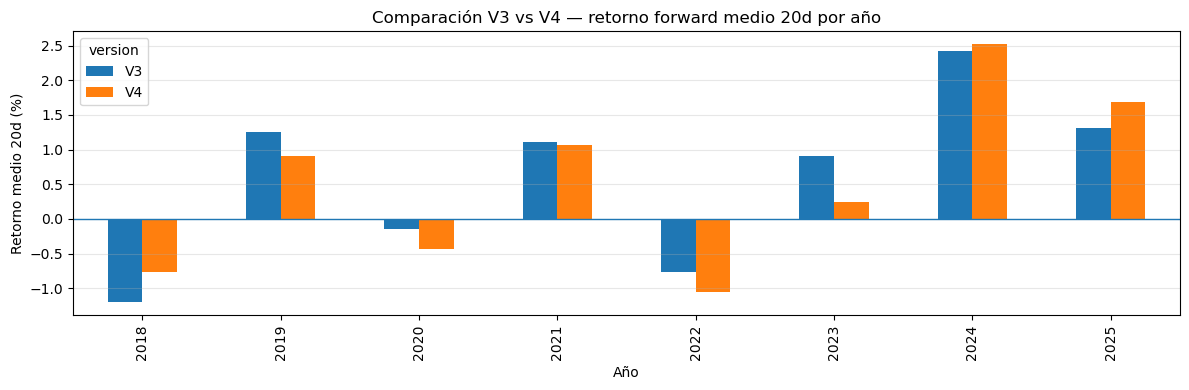

In [8]:
# ============================================================
# 07 — COMPARACIÓN V3 vs V4
# ============================================================

def find_v3_candidates():
    for p in V3_CANDIDATE_PATHS:
        if p.exists():
            return p
    return None

v3_path = find_v3_candidates()
summary_v3_v4_comparison = pd.DataFrame()

if v3_path is None:
    print("No encontré candidatos V3 exportados. Se omite comparación V3 vs V4.")
else:
    print("Candidatos V3 encontrados:", v3_path.resolve())
    df_v3 = pd.read_csv(v3_path)
    df_v3["Date"] = pd.to_datetime(df_v3["Date"])
    df_v3["Year"] = df_v3["Date"].dt.year

    # Llave de señal para medir retención.
    key_cols = ["Ticker", "Date"]
    v3_keys = df_v3[key_cols].drop_duplicates()
    v4_keys = df_candidates[key_cols].drop_duplicates()
    retained = v3_keys.merge(v4_keys.assign(in_v4=True), on=key_cols, how="left")
    retained["in_v4"] = retained["in_v4"].fillna(False).astype(bool)

    n_v3 = len(v3_keys)
    n_v4 = len(v4_keys)
    n_retained = int(retained["in_v4"].sum())
    n_removed = n_v3 - n_retained

    def build_version_summary(df_in, version):
        return pd.DataFrame([{
            "version": version,
            "n_candidates": int(len(df_in)),
            "n_tickers": int(df_in["Ticker"].nunique()),
            "first_date": df_in["Date"].min(),
            "last_date": df_in["Date"].max(),
            "ret5_mean": df_in["ret_fwd_5d"].mean() if "ret_fwd_5d" in df_in.columns else np.nan,
            "ret10_mean": df_in["ret_fwd_10d"].mean() if "ret_fwd_10d" in df_in.columns else np.nan,
            "ret20_mean": df_in["ret_fwd_20d"].mean() if "ret_fwd_20d" in df_in.columns else np.nan,
            "ret20_median": df_in["ret_fwd_20d"].median() if "ret_fwd_20d" in df_in.columns else np.nan,
            "pct_pos_20d": pct_pos(df_in["ret_fwd_20d"]) if "ret_fwd_20d" in df_in.columns else np.nan,
            "mfe20_mean": df_in["mfe_fwd_20d"].mean() if "mfe_fwd_20d" in df_in.columns else np.nan,
            "mae20_mean": df_in["mae_fwd_20d"].mean() if "mae_fwd_20d" in df_in.columns else np.nan,
        }])

    summary_v3_v4_comparison = pd.concat([
        build_version_summary(df_v3, "V3"),
        build_version_summary(df_candidates, "V4"),
    ], ignore_index=True)

    print("Resumen retención V3 → V4")
    retention_df = pd.DataFrame([{
        "n_v3_unique_signals": n_v3,
        "n_v4_unique_signals": n_v4,
        "n_v3_retained_by_v4": n_retained,
        "n_v3_removed_by_v4": n_removed,
        "pct_v3_retained": n_retained / n_v3 if n_v3 else np.nan,
        "pct_v3_removed": n_removed / n_v3 if n_v3 else np.nan,
    }])
    display(retention_df.style.format({"pct_v3_retained": "{:.2%}", "pct_v3_removed": "{:.2%}"}))

    print("Comparación global V3 vs V4")
    display(summary_v3_v4_comparison.style.format(fmt))

    # Comparación por año, si V3 contiene métricas forward.
    common_metrics = [c for c in ["ret_fwd_20d", "mfe_fwd_20d", "mae_fwd_20d"] if c in df_v3.columns]
    if "ret_fwd_20d" in common_metrics:
        v3_year = df_v3.groupby("Year").agg(
            n_candidates=("Ticker", "count"),
            ret20_mean=("ret_fwd_20d", "mean"),
            ret20_median=("ret_fwd_20d", "median"),
            pct_pos_20d=("ret_fwd_20d", pct_pos),
        ).reset_index().assign(version="V3")
        v4_year = df_candidates.groupby("Year").agg(
            n_candidates=("Ticker", "count"),
            ret20_mean=("ret_fwd_20d", "mean"),
            ret20_median=("ret_fwd_20d", "median"),
            pct_pos_20d=("ret_fwd_20d", pct_pos),
        ).reset_index().assign(version="V4")
        comparison_by_year = pd.concat([v3_year, v4_year], ignore_index=True)
        print("Comparación por año V3 vs V4")
        display(comparison_by_year.sort_values(["Year", "version"]).style.format(fmt))

        fig, ax = plt.subplots(figsize=(12, 4))
        pivot = comparison_by_year.pivot(index="Year", columns="version", values="ret20_mean") * 100
        pivot.plot(kind="bar", ax=ax)
        ax.axhline(0, linewidth=1)
        ax.set_title("Comparación V3 vs V4 — retorno forward medio 20d por año")
        ax.set_xlabel("Año")
        ax.set_ylabel("Retorno medio 20d (%)")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

## 8. Gráficos agregados V4

Los gráficos muestran el comportamiento de todo el conjunto de señales V4, no ejemplos aislados.

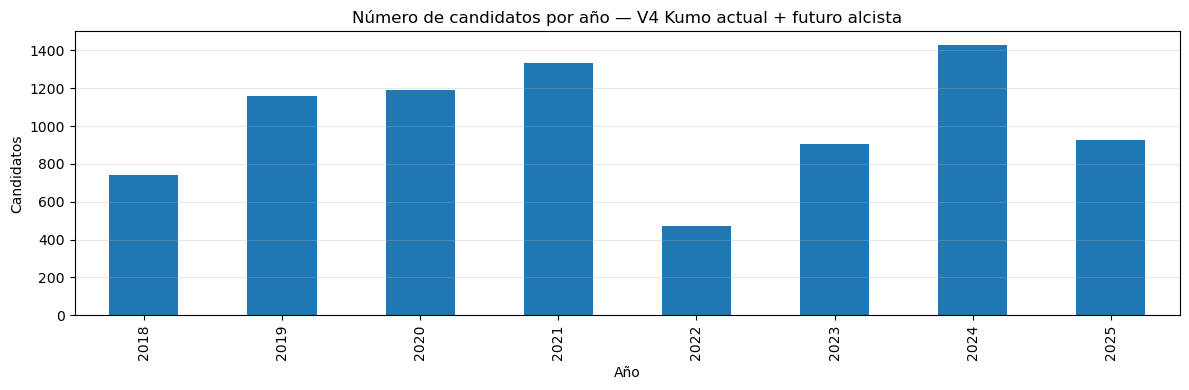

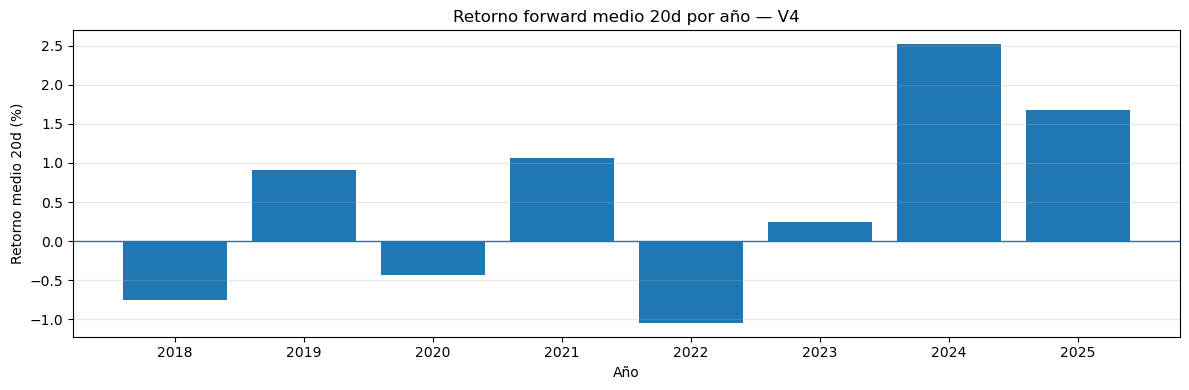

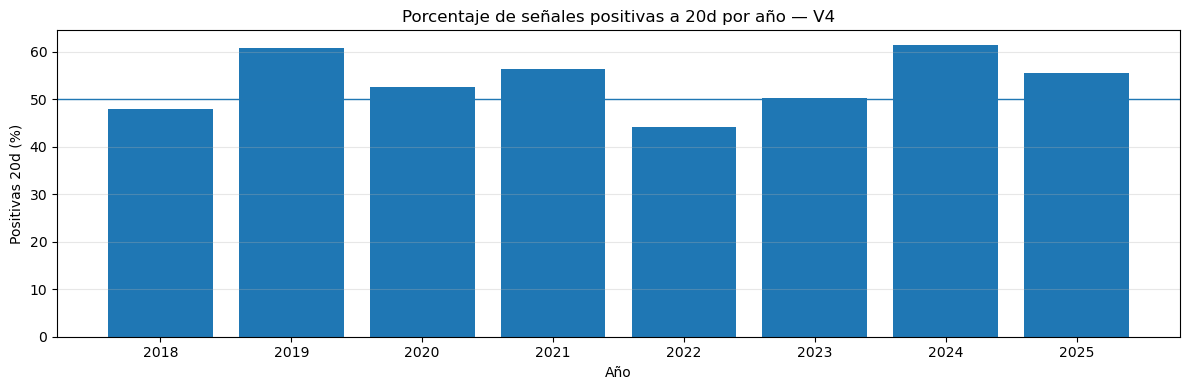

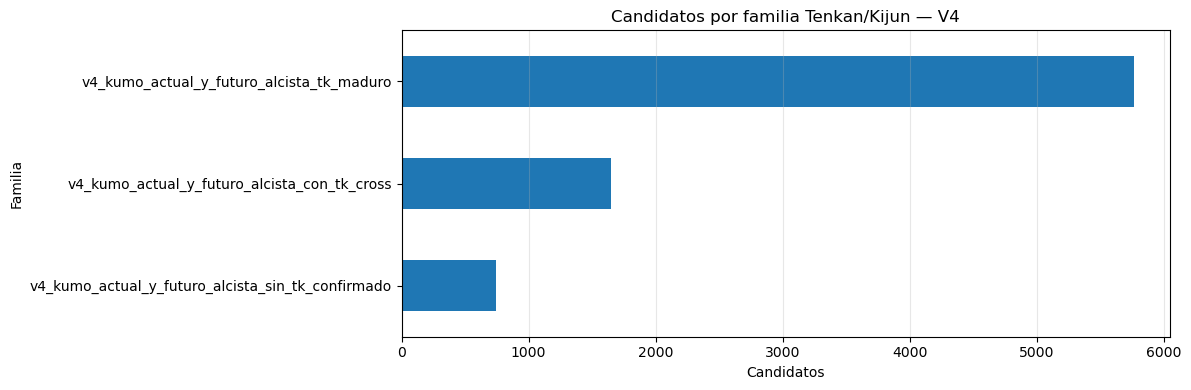

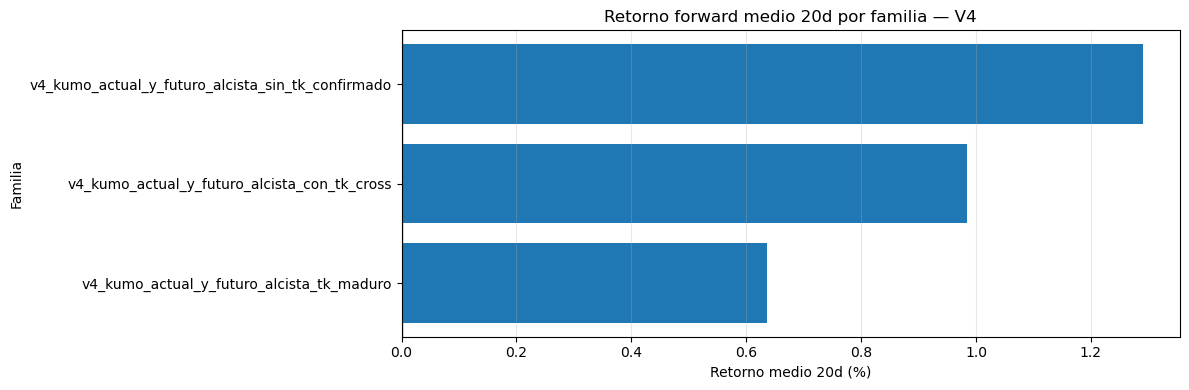

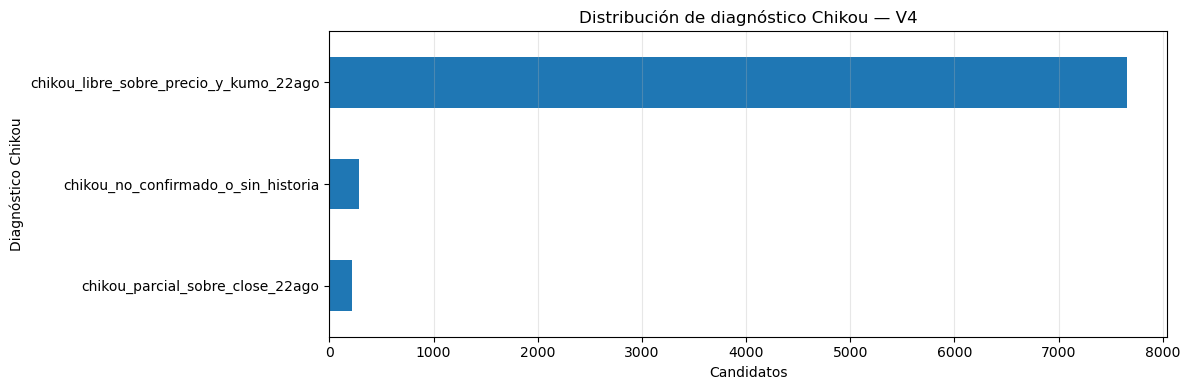

In [9]:
# ============================================================
# 08 — GRÁFICOS AGREGADOS V4
# ============================================================

# Candidatos por año
fig, ax = plt.subplots(figsize=(12, 4))
summary_by_year.plot(x="Year", y="n_candidates", kind="bar", ax=ax, legend=False)
ax.set_title("Número de candidatos por año — V4 Kumo actual + futuro alcista")
ax.set_xlabel("Año")
ax.set_ylabel("Candidatos")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Retorno forward medio a 20 días por año
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(summary_by_year["Year"].astype(str), summary_by_year["ret20_mean"] * 100)
ax.axhline(0, linewidth=1)
ax.set_title("Retorno forward medio 20d por año — V4")
ax.set_xlabel("Año")
ax.set_ylabel("Retorno medio 20d (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Win rate 20d por año
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(summary_by_year["Year"].astype(str), summary_by_year["pct_pos_20d"] * 100)
ax.axhline(50, linewidth=1)
ax.set_title("Porcentaje de señales positivas a 20d por año — V4")
ax.set_xlabel("Año")
ax.set_ylabel("Positivas 20d (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Candidatos por familia
fig, ax = plt.subplots(figsize=(12, 4))
summary_by_family.sort_values("n_candidates", ascending=True).plot(
    x="entry_family", y="n_candidates", kind="barh", ax=ax, legend=False
)
ax.set_title("Candidatos por familia Tenkan/Kijun — V4")
ax.set_xlabel("Candidatos")
ax.set_ylabel("Familia")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Retorno 20d por familia
fig, ax = plt.subplots(figsize=(12, 4))
plot_family = summary_by_family.sort_values("ret20_mean", ascending=True).copy()
ax.barh(plot_family["entry_family"], plot_family["ret20_mean"] * 100)
ax.axvline(0, linewidth=1)
ax.set_title("Retorno forward medio 20d por familia — V4")
ax.set_xlabel("Retorno medio 20d (%)")
ax.set_ylabel("Familia")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Diagnóstico Chikou
fig, ax = plt.subplots(figsize=(12, 4))
summary_by_chikou.sort_values("n_candidates", ascending=True).plot(
    x="chikou_diagnostic_status", y="n_candidates", kind="barh", ax=ax, legend=False
)
ax.set_title("Distribución de diagnóstico Chikou — V4")
ax.set_xlabel("Candidatos")
ax.set_ylabel("Diagnóstico Chikou")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Auditorías metodológicas 

Esta sección prueba que el screener V4 no está permitiendo entradas long inválidas.

In [10]:
# ============================================================
# 09 — AUDITORÍAS METODOLÓGICAS V4
# ============================================================

audit_checks = {
    "all_price_above_kumo": bool(df_candidates["precio_sobre_kumo_actual"].fillna(False).all()),
    "all_kumo_actual_bullish": bool(df_candidates["kumo_actual_alcista"].fillna(False).all()),
    "all_kumo_future_bullish": bool(df_candidates["kumo_futuro_alcista"].fillna(False).all()),
    "all_kumo_bullish_required": bool(df_candidates["kumo_alcista_requerido"].fillna(False).all()),
    "all_ha2_bullish_above_kumo": bool(df_candidates["HA2_Bullish_sobre_kumo"].fillna(False).all()),
    "all_stoch_cross_up": bool(df_candidates["stoch_cross_up_from_below"].fillna(False).all()),
    "all_volume_confirmed": bool(df_candidates["volume_confirmed"].fillna(False).all()),
    "all_liquidity_ok": bool(df_candidates["liquidity_ok"].fillna(False).all()),
    "no_2026_candidates": bool((df_candidates["Date"] <= ANALYSIS_END_DATE).all()),
}

audit_df = pd.DataFrame([{"check": k, "ok": v} for k, v in audit_checks.items()])
display(audit_df)

failed = audit_df[~audit_df["ok"]]
if len(failed) > 0:
    raise AssertionError("Fallan auditorías metodológicas V4: " + ", ".join(failed["check"].tolist()))

print("Todas las auditorías metodológicas obligatorias V4 están OK.")
print("Nota: Tenkan/Kijun y Chikou se mantienen como diagnóstico/ranking en esta versión, no como veto duro.")

,check,ok
0,all_price_above_kumo,True
1,all_kumo_actual_bullish,True
2,all_kumo_future_bullish,True
3,all_kumo_bullish_required,True
4,all_ha2_bullish_above_kumo,True
5,all_stoch_cross_up,True
6,all_volume_confirmed,True
7,all_liquidity_ok,True
8,no_2026_candidates,True


Todas las auditorías metodológicas obligatorias V4 están OK.
Nota: Tenkan/Kijun y Chikou se mantienen como diagnóstico/ranking en esta versión, no como veto duro.


## 10. Exportación

El 04C consume únicamente los tickers candidatos

In [11]:
# ============================================================
# 10 — EXPORTACIÓN V4
# ============================================================

candidate_cols = [
    "Ticker", "Date", "signal_date", "candidate_entry_date", "entry_timing", "delay_days",
    "source_signal_block", "entry_family", "tk_confirmation_status", "chikou_diagnostic_status", "accepted_signal",
    "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume",
    "Volume_Rel", "Dollar_Volume_MA20", "liquidity_ok",
    "precio_sobre_kumo_actual", "precio_dentro_kumo_actual", "precio_bajo_kumo_actual",
    "kumo_actual_alcista", "kumo_futuro_alcista", "kumo_alcista_requerido",
    "kumo_actual_thickness_abs", "kumo_actual_thickness_pct",
    "HA_Bullish", "HA_Bullish_prev1", "HA2_Bullish", "HA2_Bullish_sobre_kumo",
    "Stoch_K", "Stoch_D", "Stoch_K_prev1", "Stoch_D_prev1", "stoch_cross_up_from_below", "stoch_not_extreme_overbought",
    "Ichimoku_Tenkan", "Ichimoku_Kijun", "tenkan_sobre_kijun", "tk_cross_up_today", "tk_cross_up_recent",
    "precio_sobre_tenkan", "precio_sobre_kijun", "precio_sobre_tenkan_y_kijun",
    "Close_22ago", "High_22ago", "chikou_above_close_22ago", "chikou_above_high_22ago", "chikou_above_kumo_22ago",
    "Senkou_A_actual", "Senkou_B_actual", "Kumo_Actual_Top", "Kumo_Actual_Bottom",
    "Senkou_A_futuro", "Senkou_B_futuro", "Kumo_Futuro_Top", "Kumo_Futuro_Bottom",
    "technical_priority_score", "Year",
]
for w in FORWARD_WINDOWS:
    candidate_cols += [f"ret_fwd_{w}d", f"mfe_fwd_{w}d", f"mae_fwd_{w}d"]

candidate_cols = [c for c in candidate_cols if c in df_candidates.columns]
df_candidates_export = df_candidates[candidate_cols].copy()

df_candidates_export.to_csv(CANDIDATES_CSV, index=False)
try:
    df_candidates_export.to_parquet(CANDIDATES_PARQUET, index=False)
    parquet_candidates_saved = True
except Exception as e:
    parquet_candidates_saved = False
    print("No se pudo guardar candidatos en parquet:", e)

selected_daily_cols = [
    "Ticker", "Date", "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj", "Volume",
    "row_operational_ok", "Volume_Rel", "Dollar_Volume_MA20", "liquidity_ok",
    "precio_sobre_kumo_actual", "precio_dentro_kumo_actual", "precio_bajo_kumo_actual",
    "kumo_actual_alcista", "kumo_futuro_alcista", "kumo_alcista_requerido",
    "kumo_actual_thickness_abs", "kumo_actual_thickness_pct",
    "HA_Bullish", "HA_Bullish_prev1", "HA2_Bullish", "HA2_Bullish_sobre_kumo",
    "Stoch_K", "Stoch_D", "stoch_cross_up_from_below", "stoch_not_extreme_overbought",
    "Ichimoku_Tenkan", "Ichimoku_Kijun", "tenkan_sobre_kijun", "tk_cross_up_today", "tk_cross_up_recent",
    "Close_22ago", "High_22ago", "chikou_above_close_22ago", "chikou_above_high_22ago", "chikou_above_kumo_22ago", "chikou_diagnostic_status",
    "entry_condition_base", "entry_event_new_condition", "entry_event_after_cooldown", "entry_family", "technical_priority_score",
    "Senkou_A_actual", "Senkou_B_actual", "Kumo_Actual_Top", "Kumo_Actual_Bottom",
]
selected_daily_cols = [c for c in selected_daily_cols if c in df_audit.columns]
df_daily_export = df_audit[selected_daily_cols].copy()
df_daily_export.to_csv(DAILY_AUDIT_CSV, index=False)
try:
    df_daily_export.to_parquet(DAILY_AUDIT_PARQUET, index=False)
    parquet_daily_saved = True
except Exception as e:
    parquet_daily_saved = False
    print("No se pudo guardar daily audit parquet:", e)

summary_global.to_csv(SUMMARY_GLOBAL_CSV, index=False)
summary_by_year.to_csv(SUMMARY_BY_YEAR_CSV, index=False)
summary_by_family.to_csv(SUMMARY_BY_FAMILY_CSV, index=False)
summary_by_tk.to_csv(SUMMARY_BY_TK_CSV, index=False)
summary_by_chikou.to_csv(SUMMARY_BY_CHIKOU_CSV, index=False)
summary_horizon.to_csv(SUMMARY_HORIZON_CSV, index=False)
if not summary_v3_v4_comparison.empty:
    summary_v3_v4_comparison.to_csv(SUMMARY_V3_V4_COMPARISON_CSV, index=False)

summary = {
    "run_timestamp": run_timestamp,
    "analysis_start_date": str(ANALYSIS_START_DATE.date()),
    "analysis_end_date": str(ANALYSIS_END_DATE.date()),
    "ichimoku": {"tenkan": ICHIMOKU_TENKAN, "kijun": ICHIMOKU_KIJUN, "senkou_b": ICHIMOKU_SENKOU_B, "shift": ICHIMOKU_SHIFT},
    "contract": {
        "price_above_kumo_required": REQUIRE_PRICE_ABOVE_KUMO,
        "kumo_actual_bullish_required": REQUIRE_KUMO_ACTUAL_BULLISH,
        "kumo_future_bullish_required": REQUIRE_KUMO_FUTURE_BULLISH,
        "ha2_bullish_required": REQUIRE_HA2_BULLISH,
        "second_ha_signal_above_kumo": True,
        "stoch_cross_up_required": REQUIRE_STOCH_CROSS_UP,
        "volume_confirmation_required": REQUIRE_VOLUME_CONFIRMATION,
        "liquidity_required": REQUIRE_LIQUIDITY,
        "tk_cross_is_confirmation_not_hard_veto": True,
        "chikou_is_diagnostic_not_hard_veto_in_v4": True,
        "generate_only_new_condition_events": GENERATE_ONLY_NEW_CONDITION_EVENTS,
        "signal_cooldown_days": SIGNAL_COOLDOWN_DAYS,
    },
    "n_rows_used": int(len(df_audit)),
    "n_candidates": int(len(df_candidates_export)),
    "n_candidate_tickers": int(df_candidates_export["Ticker"].nunique()),
    "audit_checks": audit_checks,
    "files": {
        "daily_audit_csv": str(DAILY_AUDIT_CSV.resolve()),
        "daily_audit_parquet": str(DAILY_AUDIT_PARQUET.resolve()) if parquet_daily_saved else None,
        "candidates_csv": str(CANDIDATES_CSV.resolve()),
        "candidates_parquet": str(CANDIDATES_PARQUET.resolve()) if parquet_candidates_saved else None,
        "summary_global": str(SUMMARY_GLOBAL_CSV.resolve()),
        "summary_by_year": str(SUMMARY_BY_YEAR_CSV.resolve()),
        "summary_by_family": str(SUMMARY_BY_FAMILY_CSV.resolve()),
        "summary_by_tk": str(SUMMARY_BY_TK_CSV.resolve()),
        "summary_by_chikou": str(SUMMARY_BY_CHIKOU_CSV.resolve()),
        "summary_horizon": str(SUMMARY_HORIZON_CSV.resolve()),
        "summary_v3_v4_comparison": str(SUMMARY_V3_V4_COMPARISON_CSV.resolve()) if not summary_v3_v4_comparison.empty else None,
    }
}

with open(SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Exportación completa V4.")
print("Candidatos:", CANDIDATES_CSV.resolve())
print("Resumen JSON:", SUMMARY_JSON.resolve())

Exportación completa V4.
Candidatos: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4/df_nb04b_v4_entry_candidates.csv
Resumen JSON: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4/summary_nb04b_v4.json


## 11. Conclusiones pendientes de ejecución

Este notebook queda preparado para validar la hipótesis V4:

> Exigir que la nube actual esté también en configuración alcista debería reducir señales menos alineadas con la lectura tradicional de Ichimoku y, potencialmente, mejorar la calidad forward del screener.


1. `summary_nb04b_v4_global.csv`
2. `summary_nb04b_v4_by_year.csv`
3. `summary_nb04b_v4_by_family.csv`
4. `summary_nb04b_v4_by_tk_confirmation.csv`
5. `summary_nb04b_v4_by_chikou_diagnostic.csv`
6. `summary_nb04b_v4_forward_horizon_completeness.csv`
7. `summary_nb04b_v3_vs_v4_comparison.csv`, si V3 existe localmente.
